# Trabalho 08 — Reconhecimento de Flores Iris com Perceptron Multicamadas

| | |
|---|---|
| **Disciplina** | EL056 — Redes Neurais Artificiais (PPGEELT/UFU) |

**Objetivo.** Treinar uma rede Perceptron Multicamadas (MLP), implementada **do zero em NumPy**, para
classificar as três espécies do conjunto Iris (*Setosa*, *Versicolour*, *Virginica*; 50 amostras cada)
a partir de quatro medidas em cm (comprimento/largura de sépala e pétala), usando **Softmax** na camada
de saída e **entropia cruzada** como função de custo.

> Este notebook usa exatamente o mesmo código do script `iris_mlp.py` (mesmas funções, mesma semente e
> mesma configuração padrão). A última seção confere que os resultados de ambos são idênticos.

## 2. Imports e configuração

Bibliotecas: `numpy` (álgebra linear e a rede neural inteira), `pandas`/`openpyxl` (leitura da planilha),
`matplotlib` (figuras). O `scikit-learn` só aparece na Seção 13, como baseline. Todas as fontes de
aleatoriedade usam geradores `np.random.default_rng` criados a partir de `SEED = 42`; cada etapa
(divisão, inicialização, embaralhamento dos mini-batches) recebe seu próprio gerador, de modo que a
ordem de execução das células não altera os resultados.

In [1]:
import json
import logging
import platform
import time
from pathlib import Path
from typing import Callable, Dict, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s", datefmt="%H:%M:%S", force=True)
LOGGER = logging.getLogger("iris_mlp")

DATA = Path("iris_data.xlsx")
OUTDIR = Path("figs")
OUTDIR.mkdir(exist_ok=True)

In [2]:
SEED: int = 42


ATRIBUTOS: List[str] = ["sepal_length", "sepal_width", "petal_length", "petal_width"]


CLASSES: List[str] = ["Iris-setosa", "Iris-versicolor", "Iris-virginica"]


CORES: List[str] = ["#0072B2", "#E69F00", "#009E73"]


CORRECOES_UCI: Dict[int, List[float]] = {
    34: [4.9, 3.1, 1.5, 0.2],
    37: [4.9, 3.6, 1.4, 0.1],
}


ESTATISTICAS_UCI: Dict[str, Tuple[float, float, float, float, float]] = {
    # min, max, media, desvio-padrao, correlacao com a classe
    "sepal_length": (4.3, 7.9, 5.84, 0.83, 0.7826),
    "sepal_width": (2.0, 4.4, 3.05, 0.43, -0.4194),
    "petal_length": (1.0, 6.9, 3.76, 1.76, 0.9490),
    "petal_width": (0.1, 2.5, 1.20, 0.76, 0.9565),
}


CONFIG_PADRAO: Dict[str, object] = {
    "hidden": [8],
    "activation": "tanh",
    "lr": 0.05,
    "momentum": 0.9,
    "epochs": 2000,
    "batch_size": 16,
    "patience": 100,
}

print("Configuração padrão:", CONFIG_PADRAO, "| SEED =", SEED)

Configuração padrão: {'hidden': [8], 'activation': 'tanh', 'lr': 0.05, 'momentum': 0.9, 'epochs': 2000, 'batch_size': 16, 'patience': 100} | SEED = 42


## 3. Carregamento dos dados

A planilha `iris_data.xlsx` não tem cabeçalho e armazena os atributos como **texto**; por isso a leitura usa
`header=None, names=[...]` e cada coluna é convertida explicitamente para `float64` (aceitando vírgula
decimal, por robustez). A função valida o formato (150 × 5), a ausência de valores faltantes e os rótulos.

In [3]:
def carregar_dados(caminho: str | Path, corrigir_uci: bool = True) -> pd.DataFrame:
    """Carrega o ``iris_data.xlsx`` (sem cabecalho) e converte atributos para float.

    Parameters
    ----------
    caminho : str or Path
        Caminho da planilha (150 linhas x 5 colunas, sem cabecalho).
    corrigir_uci : bool, default True
        Se ``True``, aplica as correcoes das amostras 35 e 38 documentadas no
        ``iris_names.txt`` (valores do artigo original de Fisher, 1936).

    Returns
    -------
    pandas.DataFrame
        Colunas ``ATRIBUTOS`` (float64) + ``classe`` (str) + ``y`` (int 0..2).
    """
    df = pd.read_excel(caminho, header=None, names=ATRIBUTOS + ["classe"], engine="openpyxl")
    for col in ATRIBUTOS:  # celulas armazenadas como TEXTO -> float
        df[col] = pd.to_numeric(
            df[col].astype(str).str.strip().str.replace(",", ".", regex=False), errors="raise"
        ).astype(np.float64)
    df["classe"] = df["classe"].astype(str).str.strip()
    if df.shape != (150, 5) or df.isna().any().any():
        raise ValueError(f"Planilha inesperada: shape={df.shape}, NaN={df.isna().sum().sum()}")
    if sorted(df["classe"].unique()) != CLASSES:
        raise ValueError(f"Rotulos inesperados: {df['classe'].unique()}")
    if corrigir_uci:
        for idx, valores in CORRECOES_UCI.items():
            antes = df.loc[idx, ATRIBUTOS].to_numpy(dtype=float)
            df.loc[idx, ATRIBUTOS] = valores
            LOGGER.info("Amostra %d corrigida: %s -> %s", idx + 1, antes.tolist(), valores)
    df["y"] = df["classe"].map({c: i for i, c in enumerate(CLASSES)}).astype(int)
    return df

In [4]:
bruto = pd.read_excel(DATA, header=None)
print("Tipos das células na planilha (openpyxl):", {type(v).__name__ for v in bruto.iloc[:, :4].to_numpy().ravel()})

df_original = carregar_dados(DATA, corrigir_uci=False)
print("shape:", df_original.shape)
print(df_original.dtypes)
print(df_original["classe"].value_counts())
df_original.head()

Tipos das células na planilha (openpyxl): {'float64'}


shape: (150, 6)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
classe              str
y                 int64
dtype: object
classe
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,classe,y
0,5.1,3.5,1.4,0.2,Iris-setosa,0
1,4.9,3.0,1.4,0.2,Iris-setosa,0
2,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5.0,3.6,1.4,0.2,Iris-setosa,0


## 4. Tratamento das amostras 35 e 38

A documentação UCI (`iris_names.txt`) informa que duas linhas divergem do artigo de Fisher (1936):

| Amostra | Planilha | Fisher (1936) | Atributo(s) com erro |
|---|---|---|---|
| 35 | 4.9, 3.1, 1.5, **0.1** | 4.9, 3.1, 1.5, **0.2** | petal width |
| 38 | 4.9, **3.1**, **1.5**, 0.1 | 4.9, **3.6**, **1.4**, 0.1 | sepal width, petal length |

**Decisão: corrigir (`CORRIGIR_UCI = True`).** Justificativas: (i) os valores corretos são conhecidos e
documentados pela própria fonte, logo não se trata de imputação; (ii) na planilha as duas linhas são
**idênticas** (duplicata espúria), o que dá peso dobrado a um único ponto; (iii) a correção restaura a
fidelidade ao dado original de Fisher. O impacto prático é desprezível (ambas são *Setosa*, classe
linearmente separável), mas a flag permite reproduzir a versão UCI sem correção.

In [5]:
CORRIGIR_UCI = True

print("Antes (planilha):")
display(df_original.loc[[34, 37], ATRIBUTOS + ["classe"]].rename(index=lambda i: f"amostra {i + 1}"))
df = carregar_dados(DATA, corrigir_uci=CORRIGIR_UCI)
print("Depois (CORRIGIR_UCI = %s):" % CORRIGIR_UCI)
display(df.loc[[34, 37], ATRIBUTOS + ["classe"]].rename(index=lambda i: f"amostra {i + 1}"))
print("Linhas duplicadas na planilha:", int(df_original.duplicated(ATRIBUTOS + ["classe"]).sum()),
      "| após correção:", int(df.duplicated(ATRIBUTOS + ["classe"]).sum()))
X = df[ATRIBUTOS].to_numpy(dtype=np.float64)
y = df["y"].to_numpy()

Antes (planilha):


,sepal_length,sepal_width,petal_length,petal_width,classe
amostra 35,4.9,3.1,1.5,0.1,Iris-setosa
amostra 38,4.9,3.1,1.5,0.1,Iris-setosa


12:49:52 INFO Amostra 35 corrigida: [4.9, 3.1, 1.5, 0.1] -> [4.9, 3.1, 1.5, 0.2]


12:49:52 INFO Amostra 38 corrigida: [4.9, 3.1, 1.5, 0.1] -> [4.9, 3.6, 1.4, 0.1]


Depois (CORRIGIR_UCI = True):


,sepal_length,sepal_width,petal_length,petal_width,classe
amostra 35,4.9,3.1,1.5,0.2,Iris-setosa
amostra 38,4.9,3.6,1.4,0.1,Iris-setosa


Linhas duplicadas na planilha: 3 | após correção: 1


## 5. Análise exploratória

Estatísticas descritivas, comparação com a tabela do `iris_names.txt` (desvio-padrão amostral, $n-1$;
correlação de Pearson com o rótulo codificado 0/1/2), matriz de dispersão, boxplots e correlação.

In [6]:
df.groupby("classe")[ATRIBUTOS].describe().T.round(2)

classe              Iris-setosa  Iris-versicolor  Iris-virginica
sepal_length count        50.00            50.00           50.00
             mean          5.01             5.94            6.59
             std           0.35             0.52            0.64
             min           4.30             4.90            4.90
             25%           4.80             5.60            6.22
             50%           5.00             5.90            6.50
             75%           5.20             6.30            6.90
             max           5.80             7.00            7.90
sepal_width  count        50.00            50.00           50.00
             mean          3.43             2.77            2.97
             std           0.38             0.31            0.32
             min           2.30             2.00            2.20
             25%           3.20             2.52            2.80
             50%           3.40             2.80            3.00
             75%           3.68             3.00            3.18
             max           4.40             3.40            3.80
petal_length count        50.00            50.00           50.00
             mean          1.46             4.26            5.55
             std           0.17             0.47            0.55
             min           1.00             3.00            4.50
             25%           1.40             4.00            5.10
             50%           1.50             4.35            5.55
             75%           1.58             4.60            5.88
             max           1.90             5.10            6.90
petal_width  count        50.00            50.00           50.00
             mean          0.25             1.33            2.03
             std           0.11             0.20            0.27
             min           0.10             1.00            1.40
             25%           0.20             1.20            1.80
             50%           0.20             1.30            2.00
             75%           0.30             1.50            2.30
             max           0.60             1.80            2.50

In [7]:
def comparar_estatisticas_uci(df: pd.DataFrame) -> Dict[str, Dict[str, float]]:
    """Estatisticas calculadas (DP amostral, ddof=1) x valores do iris_names.txt."""
    out = {}
    for a in ATRIBUTOS:
        v = df[a]
        out[a] = {"min": float(v.min()), "max": float(v.max()), "media": float(v.mean()),
                  "dp": float(v.std(ddof=1)), "corr_classe": float(np.corrcoef(v, df["y"])[0, 1]),
                  "uci": dict(zip(["min", "max", "media", "dp", "corr_classe"], ESTATISTICAS_UCI[a]))}
    return out

In [8]:
linhas = []
for nome, dados in (("planilha", df_original), ("corrigido", df)):
    for a, v in comparar_estatisticas_uci(dados).items():
        linhas.append({"versão": nome, "atributo": a, **{k: round(v[k], 4) for k in ("min", "max", "media", "dp", "corr_classe")}})
for a, (mn, mx, me, dp, cc) in ESTATISTICAS_UCI.items():
    linhas.append({"versão": "iris_names.txt", "atributo": a, "min": mn, "max": mx, "media": me, "dp": dp, "corr_classe": cc})
pd.DataFrame(linhas).pivot(index="atributo", columns="versão")

min                               max                 \
versão       corrigido iris_names.txt planilha corrigido iris_names.txt   
atributo                                                                  
petal_length       1.0            1.0      1.0       6.9            6.9   
petal_width        0.1            0.1      0.1       2.5            2.5   
sepal_length       4.3            4.3      4.3       7.9            7.9   
sepal_width        2.0            2.0      2.0       4.4            4.4   

                          media                                dp  \
versão       planilha corrigido iris_names.txt planilha corrigido   
atributo                                                            
petal_length      6.9    3.7580           3.76   3.7587    1.7653   
petal_width       2.5    1.1993           1.20   1.1987    0.7622   
sepal_length      7.9    5.8433           5.84   5.8433    0.8281   
sepal_width       4.4    3.0573           3.05   3.0540    0.4359   

                                     corr_classe                          
versão       iris_names.txt planilha   corrigido iris_names.txt planilha  
atributo                                                                  
petal_length           1.76   1.7644      0.9490         0.9490   0.9490  
petal_width            0.76   0.7632      0.9565         0.9565   0.9565  
sepal_length           0.83   0.8281      0.7826         0.7826   0.7826  
sepal_width            0.43   0.4336     -0.4267        -0.4194  -0.4194

Na versão **da planilha** (sem correção) as estatísticas reproduzem exatamente a tabela do
`iris_names.txt` (ex.: média de *sepal width* 3,054 → 3,05; correlação −0,4194). Após a correção, só
*sepal width* muda de forma perceptível (média 3,057, correlação −0,4267), pois a amostra 38 teve esse
atributo alterado de 3,1 para 3,6 — o que confirma que a tabela UCI foi calculada sobre a versão com as
discrepâncias. As pétalas apresentam correlação com a
classe ≈ 0,95, contra 0,78 e −0,42 das sépalas: são os atributos mais discriminantes.

In [9]:
def _salvar(fig: plt.Figure, outdir: Path, nome: str) -> None:
    outdir.mkdir(parents=True, exist_ok=True)
    fig.savefig(outdir / f"{nome}.pdf", bbox_inches="tight")
    fig.savefig(outdir / f"{nome}.png", dpi=300, bbox_inches="tight")


def plotar_scatter_matrix(df: pd.DataFrame, outdir: Path) -> plt.Figure:
    """Matriz de dispersao 4x4 colorida por classe (histogramas na diagonal)."""
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i, ai in enumerate(ATRIBUTOS):
        for j, aj in enumerate(ATRIBUTOS):
            ax = axes[i, j]
            for k, c in enumerate(CLASSES):
                s = df[df["y"] == k]
                if i == j:
                    ax.hist(s[ai], bins=12, alpha=0.6, color=CORES[k], label=c)
                else:
                    ax.scatter(s[aj], s[ai], s=12, alpha=0.75, color=CORES[k], label=c)
            if i == 3:
                ax.set_xlabel(f"{aj} (cm)")
            if j == 0:
                ax.set_ylabel(f"{ai} (cm)")
    handles, labels = axes[0, 1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    _salvar(fig, outdir, "scatter_matrix")
    return fig

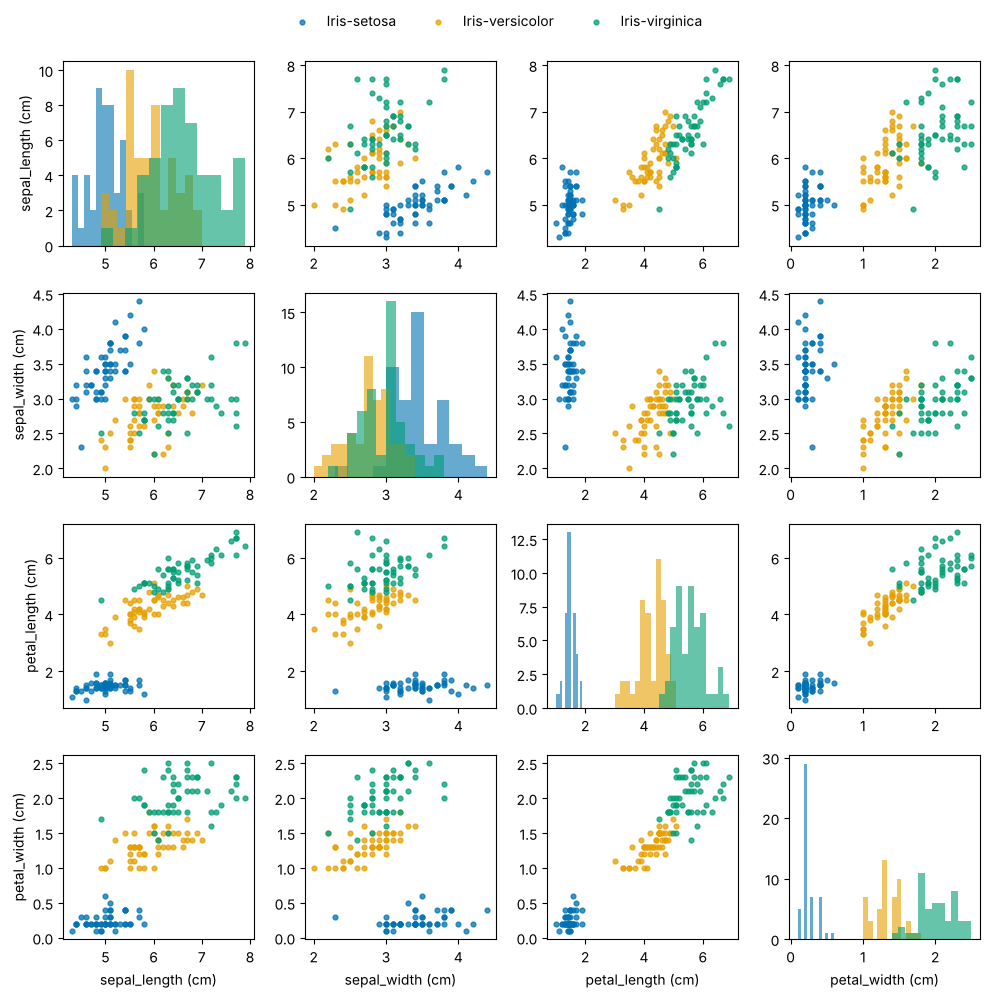

In [10]:
plotar_scatter_matrix(df, OUTDIR);

In [11]:
def plotar_boxplots(df: pd.DataFrame, outdir: Path) -> plt.Figure:
    """Boxplots de cada atributo por classe."""
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
    for ax, a in zip(axes, ATRIBUTOS):
        dados = [df.loc[df["y"] == k, a].to_numpy() for k in range(3)]
        bp = ax.boxplot(dados, patch_artist=True, widths=0.6)
        for patch, cor in zip(bp["boxes"], CORES):
            patch.set_facecolor(cor)
            patch.set_alpha(0.6)
        ax.set_xticks([1, 2, 3], ["setosa", "versicolor", "virginica"])
        ax.set_title(f"{a} (cm)")
        ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    _salvar(fig, outdir, "boxplots")
    return fig

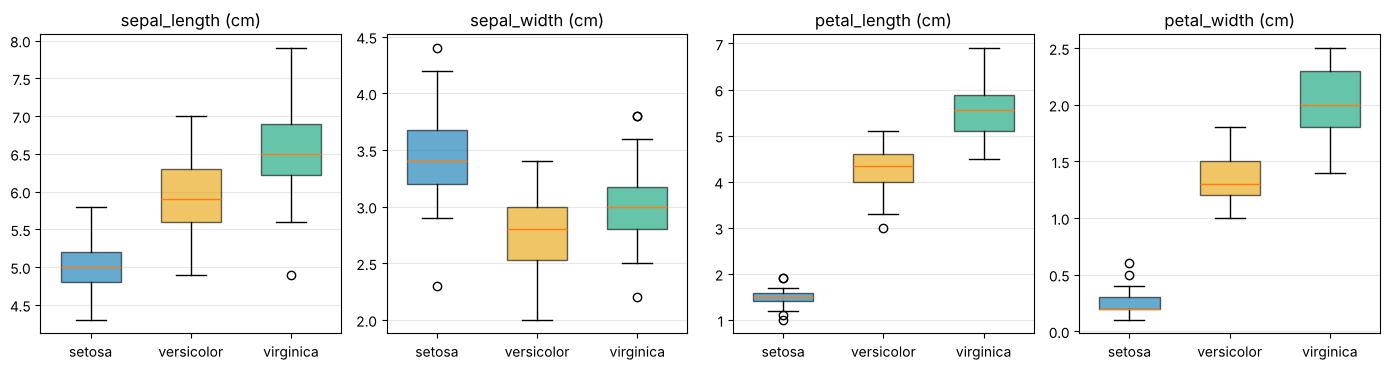

In [12]:
plotar_boxplots(df, OUTDIR);

In [13]:
def plotar_correlacao(df: pd.DataFrame, outdir: Path) -> plt.Figure:
    """Mapa de calor da correlacao de Pearson entre atributos e o rotulo (0,1,2)."""
    corr = df[ATRIBUTOS + ["y"]].corr().to_numpy()
    rotulos = ATRIBUTOS + ["classe"]
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(5), rotulos, rotation=45, ha="right")
    ax.set_yticks(range(5), rotulos)
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center",
                    color="white" if abs(corr[i, j]) > 0.6 else "black", fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout()
    _salvar(fig, outdir, "correlacao")
    return fig

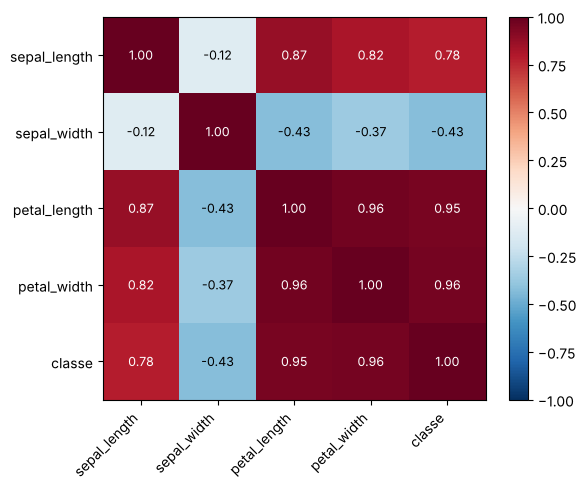

In [14]:
plotar_correlacao(df, OUTDIR);

**Leitura.** No plano das pétalas a *Setosa* forma um aglomerado isolado (linearmente separável), enquanto
*Versicolor* e *Virginica* se sobrepõem na faixa *petal length* ≈ 4,5–5,1 cm / *petal width* ≈ 1,5–1,8 cm.
Essa região de sobreposição é onde se concentrarão os erros de qualquer classificador e justifica uma
fronteira não linear (camada oculta).

## 6. Pré-processamento

* **One-hot**: $y_n \in \{0,1,2\} \mapsto \mathbf y_n \in \{0,1\}^3$, compatível com a Softmax e a CE.
* **Divisão estratificada 70/15/15** com semente fixa: por classe 35/8/7 (total 105/24/21). O
  arredondamento por classe garante a mesma proporção de espécies em todos os subconjuntos.
* **z-score** $x' = (x-\mu_{\text{treino}})/\sigma_{\text{treino}}$ — média e desvio estimados **somente no
  treino** e aplicados a validação/teste, evitando vazamento de informação. Atributos com escalas
  distintas (0,1–2,5 cm × 4,3–7,9 cm) passam a ter média 0 e variância 1, o que mantém as ativações
  `tanh`/`sigmoid` na região linear no início do treino e equilibra os gradientes.
* **k-fold estratificado** ($k=5$) para estimativas com média ± desvio-padrão (Seção 12).

In [15]:
def one_hot(y: np.ndarray, n_classes: int = 3) -> np.ndarray:
    r"""Codificacao one-hot: :math:`Y_{nk} = 1` se :math:`y_n = k`, 0 caso contrario."""
    Y = np.zeros((y.shape[0], n_classes), dtype=np.float64)
    Y[np.arange(y.shape[0]), y] = 1.0
    return Y

In [16]:
def split_estratificado(
    y: np.ndarray, fracoes: Tuple[float, float, float] = (0.70, 0.15, 0.15), seed: int = SEED
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Divisao estratificada treino/validacao/teste com semente fixa.

    Para 50 amostras por classe e fracoes 70/15/15, resultam 35/8/7 por classe
    (105/24/21 no total); o arredondamento e' feito por classe para garantir
    proporcoes identicas de cada especie em todos os subconjuntos.

    Returns
    -------
    tuple of numpy.ndarray
        Indices de treino, validacao e teste.
    """
    rng = np.random.default_rng(seed)
    tr, va, te = [], [], []
    for c in np.unique(y):
        idx = rng.permutation(np.flatnonzero(y == c))
        n_tr = int(np.floor(fracoes[0] * idx.size + 0.5))
        n_va = int(np.floor(fracoes[1] * idx.size + 0.5))
        tr.append(idx[:n_tr])
        va.append(idx[n_tr:n_tr + n_va])
        te.append(idx[n_tr + n_va:])
    return (rng.permutation(np.concatenate(tr)), rng.permutation(np.concatenate(va)),
            rng.permutation(np.concatenate(te)))

In [17]:
def kfold_estratificado(y: np.ndarray, k: int = 5, seed: int = SEED) -> List[Tuple[np.ndarray, np.ndarray]]:
    """Gera ``k`` pares (indices_treino, indices_teste) estratificados por classe."""
    rng = np.random.default_rng(seed)
    partes_por_classe = [np.array_split(rng.permutation(np.flatnonzero(y == c)), k) for c in np.unique(y)]
    folds = []
    for i in range(k):
        te = np.concatenate([p[i] for p in partes_por_classe])
        tr = np.concatenate([np.concatenate([p[j] for j in range(k) if j != i]) for p in partes_por_classe])
        folds.append((rng.permutation(tr), rng.permutation(te)))
    return folds

In [18]:
class ZScore:
    r"""Padronizacao z-score :math:`x' = (x-\mu_{treino})/\sigma_{treino}`.

    Os parametros sao estimados SOMENTE no conjunto de treino, evitando
    vazamento de informacao (data leakage) da validacao/teste.
    """

    def __init__(self) -> None:
        self.media: Optional[np.ndarray] = None
        self.desvio: Optional[np.ndarray] = None

    def fit(self, X: np.ndarray) -> "ZScore":
        self.media = X.mean(axis=0)
        self.desvio = X.std(axis=0)
        self.desvio[self.desvio == 0] = 1.0
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        return (X - self.media) / self.desvio

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform(X)

In [19]:
def preprocessar(
    X: np.ndarray, y: np.ndarray, idx_tr: np.ndarray, idx_va: np.ndarray, idx_te: np.ndarray
) -> Dict[str, object]:
    """Aplica z-score (ajustado no treino) e one-hot aos tres subconjuntos."""
    scaler = ZScore().fit(X[idx_tr])
    return {
        "scaler": scaler,
        "Xtr": scaler.transform(X[idx_tr]), "Ytr": one_hot(y[idx_tr]), "ytr": y[idx_tr],
        "Xva": scaler.transform(X[idx_va]), "Yva": one_hot(y[idx_va]), "yva": y[idx_va],
        "Xte": scaler.transform(X[idx_te]), "Yte": one_hot(y[idx_te]), "yte": y[idx_te],
    }

In [20]:
idx_tr, idx_va, idx_te = split_estratificado(y, seed=SEED)
d = preprocessar(X, y, idx_tr, idx_va, idx_te)
for nome, idx in (("treino", idx_tr), ("validação", idx_va), ("teste", idx_te)):
    print(f"{nome:10s} n={len(idx):3d} | por classe: {np.bincount(y[idx]).tolist()}")
print("média treino (padronizado):", d["Xtr"].mean(axis=0).round(12))
print("desvio treino (padronizado):", d["Xtr"].std(axis=0).round(12))
print("média do TESTE após z-score do treino:", d["Xte"].mean(axis=0).round(3), "(não precisa ser 0)")

treino     n=105 | por classe: [35, 35, 35]
validação  n= 24 | por classe: [8, 8, 8]
teste      n= 21 | por classe: [7, 7, 7]
média treino (padronizado): [ 0.  0. -0. -0.]
desvio treino (padronizado): [1. 1. 1. 1.]
média do TESTE após z-score do treino: [-0.075 -0.177 -0.042 -0.042] (não precisa ser 0)


## 7. Implementação da MLP do zero (NumPy)

### 7.1 Funções de ativação das camadas ocultas

$$\sigma(z)=\frac{1}{1+e^{-z}},\ \ \sigma'(z)=\sigma(z)[1-\sigma(z)];\qquad
\tanh'(z)=1-\tanh^2(z);\qquad \mathrm{ReLU}(z)=\max(0,z),\ \ \mathrm{ReLU}'(z)=\mathbb 1[z>0].$$

In [21]:
def sigmoid(z: np.ndarray) -> np.ndarray:
    r"""Sigmoide logistica :math:`\sigma(z) = 1/(1+e^{-z})` (com clipping numerico)."""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500.0, 500.0)))


def sigmoid_deriv(z: np.ndarray) -> np.ndarray:
    r""":math:`\sigma'(z) = \sigma(z)\,[1-\sigma(z)]`."""
    s = sigmoid(z)
    return s * (1.0 - s)

In [22]:
def tanh(z: np.ndarray) -> np.ndarray:
    r"""Tangente hiperbolica :math:`\tanh(z)`."""
    return np.tanh(z)


def tanh_deriv(z: np.ndarray) -> np.ndarray:
    r""":math:`\tanh'(z) = 1-\tanh^2(z)`."""
    return 1.0 - np.tanh(z) ** 2

In [23]:
def relu(z: np.ndarray) -> np.ndarray:
    r"""ReLU :math:`\max(0, z)`."""
    return np.maximum(0.0, z)


def relu_deriv(z: np.ndarray) -> np.ndarray:
    r""":math:`\mathrm{ReLU}'(z) = \mathbb{1}[z>0]` (subgradiente 0 em z=0)."""
    return (z > 0).astype(z.dtype)

In [24]:
ATIVACOES: Dict[str, Tuple[Callable[[np.ndarray], np.ndarray], Callable[[np.ndarray], np.ndarray]]] = {
    "sigmoid": (sigmoid, sigmoid_deriv),
    "tanh": (tanh, tanh_deriv),
    "relu": (relu, relu_deriv),
}

### 7.2 Softmax estável

$$\hat y_k=\mathrm{softmax}(\mathbf z)_k=\frac{e^{z_k}}{\sum_{j=1}^{K}e^{z_j}}=\frac{e^{z_k-m}}{\sum_{j}e^{z_j-m}},\qquad m=\max_j z_j.$$

Subtrair $m$ não altera o resultado (o fator $e^{-m}$ se cancela), mas garante $z_k-m\le 0$ e, portanto,
$e^{z_k-m}\in(0,1]$ — sem *overflow*.

In [25]:
def softmax(z: np.ndarray) -> np.ndarray:
    r"""Softmax numericamente estavel, aplicada por linha.

    .. math:: \hat y_k = \frac{e^{z_k - \max_j z_j}}{\sum_{i=1}^{K} e^{z_i - \max_j z_j}}

    A subtracao do maximo nao altera o resultado (invariancia a translacao)
    e evita overflow de ``exp`` para logits grandes.
    """
    z_desl = z - np.max(z, axis=1, keepdims=True)
    e = np.exp(z_desl)
    return e / np.sum(e, axis=1, keepdims=True)


z_teste = np.array([[1000.0, 1001.0, 1002.0], [-5.0, 0.0, 5.0]])
p = softmax(z_teste)
print(p.round(6), "| somas:", p.sum(axis=1))

[[9.00310e-02 2.44728e-01 6.65241e-01]
 [4.50000e-05 6.69300e-03 9.93262e-01]] | somas: [1. 1.]


### 7.3 Entropia cruzada categorial

$$L=-\frac{1}{N}\sum_{n=1}^{N}\sum_{k=1}^{K} y_{nk}\ln \hat y_{nk},$$

com $\hat y$ limitado a $[\varepsilon,1]$, $\varepsilon=10^{-12}$, para evitar $\ln 0$. Com one-hot, só o
termo da classe verdadeira sobrevive: $L_n=-\ln\hat y_{n,c(n)}$ (log-verossimilhança negativa).

In [26]:
def cross_entropy(y: np.ndarray, y_hat: np.ndarray, eps: float = 1e-12) -> float:
    r"""Entropia cruzada categorial media com rotulos one-hot.

    .. math:: L = -\frac{1}{N}\sum_{n=1}^{N}\sum_{k=1}^{K} y_{nk}\,\ln \hat y_{nk}

    ``y_hat`` e' limitado a ``[eps, 1]`` para evitar ``log(0)``.
    """
    return float(-np.mean(np.sum(y * np.log(np.clip(y_hat, eps, 1.0)), axis=1)))


Y_ex = one_hot(np.array([0, 1]))
print("CE previsão perfeita :", cross_entropy(Y_ex, Y_ex))
print("CE previsão uniforme :", cross_entropy(Y_ex, np.full((2, 3), 1 / 3)), "= ln 3 =", np.log(3))

CE previsão perfeita : -0.0
CE previsão uniforme : 1.0986122886681098 = ln 3 = 1.0986122886681098


### 7.4 Classe `MLP`: forward, backward e atualização

**Forward** (linhas = amostras):
$\mathbf Z^{(l)}=\mathbf A^{(l-1)}\mathbf W^{(l)}+\mathbf b^{(l)}$, $\mathbf A^{(l)}=f(\mathbf Z^{(l)})$ nas ocultas e
$\hat{\mathbf Y}=\mathrm{softmax}(\mathbf Z^{(L)})$ na saída.

**Gradiente Softmax + CE.** Com $\partial\hat y_k/\partial z_j=\hat y_k(\delta_{kj}-\hat y_j)$:
$$\frac{\partial L_n}{\partial z_j}=-\sum_k \frac{y_k}{\hat y_k}\hat y_k(\delta_{kj}-\hat y_j)=-y_j+\hat y_j\sum_k y_k=\hat y_j-y_j .$$
Logo $\boldsymbol\delta^{(L)}=(\hat{\mathbf Y}-\mathbf Y)/N$ para o custo médio no lote.

**Backpropagation:** $\nabla_{\mathbf W^{(l)}}L=\mathbf A^{(l-1)\top}\boldsymbol\delta^{(l)}$,
$\nabla_{\mathbf b^{(l)}}L=\mathbf 1^\top\boldsymbol\delta^{(l)}$,
$\boldsymbol\delta^{(l-1)}=(\boldsymbol\delta^{(l)}\mathbf W^{(l)\top})\odot f'(\mathbf Z^{(l-1)})$.

**Atualização (momentum):** $\mathbf v\leftarrow\mu\mathbf v-\eta\nabla_\theta L$, $\theta\leftarrow\theta+\mathbf v$.

**Inicialização:** Xavier/Glorot $\mathcal N(0,\,2/(n_{in}+n_{out}))$ para `sigmoid`/`tanh` e para a
camada Softmax; He $\mathcal N(0,\,2/n_{in})$ para camadas ReLU. Vieses em zero.

In [27]:
class MLP:
    r"""Perceptron Multicamadas com saida Softmax e custo de entropia cruzada.

    Parameters
    ----------
    n_entradas : int
        Numero de atributos de entrada (4 no Iris).
    ocultas : sequence of int
        Neuronios de cada camada oculta, ex.: ``[8]`` ou ``[10, 6]``.
    n_saidas : int
        Numero de classes (3).
    ativacao : {'sigmoid', 'tanh', 'relu'}
        Ativacao das camadas ocultas.
    seed : int
        Semente da inicializacao dos pesos.

    Notes
    -----
    Inicializacao: He, :math:`W\sim\mathcal N(0, 2/n_{in})`, para ReLU;
    Xavier/Glorot, :math:`W\sim\mathcal N(0, 2/(n_{in}+n_{out}))`, para
    sigmoid/tanh e para a camada Softmax. Vieses iniciam em zero.
    """

    def __init__(self, n_entradas: int, ocultas: Sequence[int], n_saidas: int,
                 ativacao: str = "tanh", seed: int = SEED) -> None:
        if ativacao not in ATIVACOES:
            raise ValueError(f"Ativacao desconhecida: {ativacao}")
        self.ativacao = ativacao
        self.f, self.df = ATIVACOES[ativacao]
        self.dims = [n_entradas, *ocultas, n_saidas]
        rng = np.random.default_rng(seed)
        self.W: List[np.ndarray] = []
        self.b: List[np.ndarray] = []
        n_camadas = len(self.dims) - 1
        for l in range(n_camadas):
            fan_in, fan_out = self.dims[l], self.dims[l + 1]
            if ativacao == "relu" and l < n_camadas - 1:
                std = np.sqrt(2.0 / fan_in)  # He
            else:
                std = np.sqrt(2.0 / (fan_in + fan_out))  # Xavier/Glorot
            self.W.append(rng.normal(0.0, std, size=(fan_in, fan_out)))
            self.b.append(np.zeros(fan_out))
        self.vW = [np.zeros_like(w) for w in self.W]
        self.vb = [np.zeros_like(b) for b in self.b]
        self._Z: List[np.ndarray] = []
        self._A: List[np.ndarray] = []

    def forward(self, X: np.ndarray) -> np.ndarray:
        r"""Propagacao direta: :math:`z^{(l)} = a^{(l-1)}W^{(l)} + b^{(l)}`,
        :math:`a^{(l)} = f(z^{(l)})` nas ocultas e :math:`\hat y = \mathrm{softmax}(z^{(L)})`."""
        self._A = [X]
        self._Z = []
        a = X
        for l in range(len(self.W)):
            z = a @ self.W[l] + self.b[l]
            self._Z.append(z)
            a = softmax(z) if l == len(self.W) - 1 else self.f(z)
            self._A.append(a)
        return a

    def backward(self, Y: np.ndarray) -> Tuple[List[np.ndarray], List[np.ndarray]]:
        r"""Retropropagacao. Na saida, Softmax + CE fornecem
        :math:`\delta^{(L)} = (\hat Y - Y)/N`; nas ocultas,
        :math:`\delta^{(l)} = (\delta^{(l+1)} W^{(l+1)\top}) \odot f'(z^{(l)})`.

        Returns
        -------
        (dW, db) : listas com os gradientes de cada camada.
        """
        N = Y.shape[0]
        delta = (self._A[-1] - Y) / N
        dW: List[np.ndarray] = [np.empty(0)] * len(self.W)
        db: List[np.ndarray] = [np.empty(0)] * len(self.W)
        for l in range(len(self.W) - 1, -1, -1):
            dW[l] = self._A[l].T @ delta
            db[l] = delta.sum(axis=0)
            if l > 0:
                delta = (delta @ self.W[l].T) * self.df(self._Z[l - 1])
        return dW, db

    def update(self, dW: List[np.ndarray], db: List[np.ndarray], lr: float, momentum: float = 0.0) -> None:
        r"""Gradiente descendente com momentum (heavy-ball):
        :math:`v \leftarrow \mu v - \eta \nabla_\theta L`, :math:`\theta \leftarrow \theta + v`."""
        for l in range(len(self.W)):
            self.vW[l] = momentum * self.vW[l] - lr * dW[l]
            self.vb[l] = momentum * self.vb[l] - lr * db[l]
            self.W[l] += self.vW[l]
            self.b[l] += self.vb[l]

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Probabilidades a posteriori estimadas (saida Softmax)."""
        return self.forward(X)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Classe de maior probabilidade (regra de decisao MAP)."""
        return np.argmax(self.forward(X), axis=1)

    def get_params(self) -> Tuple[List[np.ndarray], List[np.ndarray]]:
        """Copia profunda dos pesos (usada pelo early stopping)."""
        return [w.copy() for w in self.W], [b.copy() for b in self.b]

    def set_params(self, params: Tuple[List[np.ndarray], List[np.ndarray]]) -> None:
        """Restaura pesos salvos por :meth:`get_params`."""
        self.W = [w.copy() for w in params[0]]
        self.b = [b.copy() for b in params[1]]

    def n_parametros(self) -> int:
        """Numero total de parametros treinaveis."""
        return int(sum(w.size + b.size for w, b in zip(self.W, self.b)))

## 8. Verificação do gradiente (*gradient checking*)

Diferenças finitas centrais, $\epsilon=10^{-5}$, em **todos** os parâmetros de uma rede 4→5→4→3 (duas
ocultas, para exercitar a recursão do $\delta$), com erro relativo
$e=|g_a-g_n|/\max(|g_a|+|g_n|,10^{-12})$. Critério: $e<10^{-6}$.

In [28]:
def gradient_check(ativacao: str = "tanh", eps: float = 1e-5, seed: int = SEED) -> float:
    r"""Compara o gradiente analitico (backprop) com diferencas finitas centrais.

    .. math:: \frac{\partial L}{\partial\theta} \approx \frac{L(\theta+\epsilon)-L(\theta-\epsilon)}{2\epsilon},
       \qquad e_{rel} = \frac{|g_a-g_n|}{\max(|g_a|+|g_n|,\,10^{-12})}

    Returns
    -------
    float
        Maior erro relativo entre todos os parametros (aceitavel: < 1e-6).
    """
    rng = np.random.default_rng(seed)
    X = rng.normal(size=(6, 4))
    Y = one_hot(rng.integers(0, 3, size=6))
    rede = MLP(4, [5, 4], 3, ativacao=ativacao, seed=seed)
    rede.forward(X)
    dW, db = rede.backward(Y)
    erro_max = 0.0
    for params, grads in ((rede.W, dW), (rede.b, db)):
        for P, G in zip(params, grads):
            it = np.nditer(P, flags=["multi_index"])
            for _ in it:
                i = it.multi_index
                orig = P[i]
                P[i] = orig + eps
                lp = cross_entropy(Y, rede.forward(X))
                P[i] = orig - eps
                lm = cross_entropy(Y, rede.forward(X))
                P[i] = orig
                g_num = (lp - lm) / (2 * eps)
                erro = abs(G[i] - g_num) / max(abs(G[i]) + abs(g_num), 1e-12)
                erro_max = max(erro_max, erro)
    return float(erro_max)

In [29]:
grad_check = {a: gradient_check(a, seed=SEED) for a in ("sigmoid", "tanh", "relu")}
for a, e in grad_check.items():
    print(f"{a:8s} erro relativo máximo = {e:.3e}  ->", "OK" if e < 1e-6 else "FALHOU")
assert all(e < 1e-6 for e in grad_check.values())

sigmoid  erro relativo máximo = 2.988e-08  -> OK
tanh     erro relativo máximo = 3.452e-08  -> OK
relu     erro relativo máximo = 1.544e-09  -> OK


## 9. Treinamento (mini-batch + momentum + early stopping)

Configuração principal (justificativas na proposta/relatório):

* **Arquitetura 4 → 8 (tanh) → 3 (Softmax)**, 67 parâmetros. Uma camada oculta basta para fronteiras não
  lineares neste problema (teorema da aproximação universal); 8 neurônios dão folga sobre o mínimo
  necessário sem super-parametrizar 105 amostras de treino. `tanh` é centrada em zero (gradientes melhor
  condicionados que a sigmoide) e combina com a inicialização Xavier.
* **η = 0,05, μ = 0,9, lote = 16** (≈ 7 atualizações por época): o ruído do mini-batch ajuda a escapar de
  platôs, e o momentum acelera a descida em vales estreitos.
* **Early stopping**: até 2000 épocas, paciência de 100 épocas sobre a perda de **validação**; restauram-se
  os pesos da melhor época.

In [30]:
def acuracia(Y: np.ndarray, y_hat: np.ndarray) -> float:
    """Fracao de acertos entre rotulos one-hot e probabilidades previstas."""
    return float(np.mean(np.argmax(Y, axis=1) == np.argmax(y_hat, axis=1)))

In [31]:
def treinar(
    modelo: MLP, Xtr: np.ndarray, Ytr: np.ndarray, Xva: np.ndarray, Yva: np.ndarray,
    lr: float = 0.05, momentum: float = 0.9, epochs: int = 2000, batch_size: int = 16,
    patience: int = 100, seed: int = SEED, log_every: int = 0,
) -> Dict[str, object]:
    """Treina a MLP com mini-batch SGD + momentum e early stopping.

    O early stopping monitora a perda de validacao; apos ``patience`` epocas
    sem melhora (> 1e-6), o treino e' interrompido e os pesos da melhor epoca
    sao restaurados.

    Returns
    -------
    dict
        Historico (``loss_tr``, ``loss_va``, ``acc_tr``, ``acc_va``),
        ``best_epoch`` e ``epocas_executadas``.
    """
    rng = np.random.default_rng(seed)
    hist: Dict[str, list] = {"loss_tr": [], "loss_va": [], "acc_tr": [], "acc_va": []}
    melhor_loss, melhor_ep, espera = np.inf, 0, 0
    melhores = modelo.get_params()
    n = Xtr.shape[0]
    for ep in range(1, epochs + 1):
        perm = rng.permutation(n)
        for ini in range(0, n, batch_size):
            lote = perm[ini:ini + batch_size]
            modelo.forward(Xtr[lote])
            dW, db = modelo.backward(Ytr[lote])
            modelo.update(dW, db, lr, momentum)
        p_tr, p_va = modelo.forward(Xtr), modelo.forward(Xva)
        hist["loss_tr"].append(cross_entropy(Ytr, p_tr))
        hist["loss_va"].append(cross_entropy(Yva, p_va))
        hist["acc_tr"].append(acuracia(Ytr, p_tr))
        hist["acc_va"].append(acuracia(Yva, p_va))
        LOGGER.debug("epoca %4d | loss_tr %.4f loss_va %.4f | acc_tr %.3f acc_va %.3f", ep,
                     hist["loss_tr"][-1], hist["loss_va"][-1], hist["acc_tr"][-1], hist["acc_va"][-1])
        if log_every and ep % log_every == 0:
            LOGGER.info("epoca %4d | loss_tr %.4f loss_va %.4f | acc_tr %.3f acc_va %.3f", ep,
                        hist["loss_tr"][-1], hist["loss_va"][-1], hist["acc_tr"][-1], hist["acc_va"][-1])
        if hist["loss_va"][-1] < melhor_loss - 1e-6:
            melhor_loss, melhor_ep, espera = hist["loss_va"][-1], ep, 0
            melhores = modelo.get_params()
        else:
            espera += 1
            if espera >= patience:
                LOGGER.info("Early stopping na epoca %d (melhor epoca: %d)", ep, melhor_ep)
                break
    modelo.set_params(melhores)
    return {**hist, "best_epoch": melhor_ep, "epocas_executadas": len(hist["loss_tr"]),
            "melhor_loss_va": float(melhor_loss)}

In [32]:
config = dict(CONFIG_PADRAO)
rede = MLP(4, config["hidden"], 3, config["activation"], SEED)
print("Arquitetura:", rede.dims, "| parâmetros:", rede.n_parametros())
hist = treinar(rede, d["Xtr"], d["Ytr"], d["Xva"], d["Yva"], config["lr"], config["momentum"],
               config["epochs"], config["batch_size"], config["patience"], SEED, log_every=50)
print(f"Melhor época: {hist['best_epoch']} de {hist['epocas_executadas']} executadas | "
      f"CE val = {hist['melhor_loss_va']:.4f}")

Arquitetura: [4, 8, 3] | parâmetros: 67


12:50:00 INFO epoca   50 | loss_tr 0.0533 loss_va 0.0455 | acc_tr 0.981 acc_va 1.000


12:50:00 INFO epoca  100 | loss_tr 0.0537 loss_va 0.0592 | acc_tr 0.971 acc_va 1.000


12:50:00 INFO epoca  150 | loss_tr 0.0502 loss_va 0.0740 | acc_tr 0.971 acc_va 0.958


12:50:00 INFO Early stopping na epoca 199 (melhor epoca: 99)


Melhor época: 99 de 199 executadas | CE val = 0.0402


## 10. Curvas de aprendizado

In [33]:
def plotar_curvas(hist: Dict[str, object], outdir: Path) -> plt.Figure:
    """Curvas de perda e acuracia (treino x validacao) com a melhor epoca marcada."""
    ep = np.arange(1, len(hist["loss_tr"]) + 1)
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
    a1.plot(ep, hist["loss_tr"], color=CORES[0], label="Treino")
    a1.plot(ep, hist["loss_va"], color=CORES[1], label="Validação")
    a1.set_ylabel("Entropia cruzada")
    a1.set_yscale("log")
    a2.plot(ep, hist["acc_tr"], color=CORES[0], label="Treino")
    a2.plot(ep, hist["acc_va"], color=CORES[1], label="Validação")
    a2.set_ylabel("Acurácia")
    for ax in (a1, a2):
        ax.axvline(hist["best_epoch"], color="gray", ls="--", lw=1, label=f"Melhor época ({hist['best_epoch']})")
        ax.set_xlabel("Época")
        ax.grid(alpha=0.3)
        ax.legend()
    fig.tight_layout()
    _salvar(fig, outdir, "curvas_treino")
    return fig

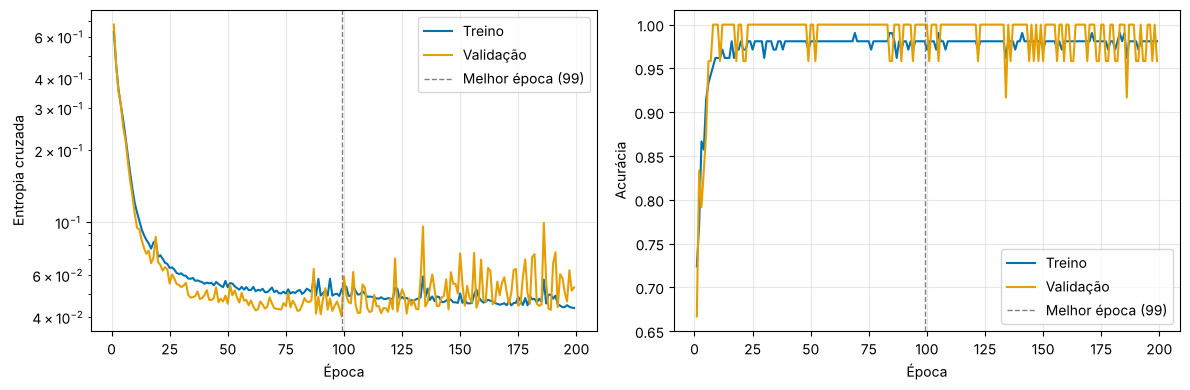

In [34]:
plotar_curvas(hist, OUTDIR);

A perda (escala log) cai rapidamente nas primeiras dezenas de épocas e estabiliza; a partir daí a perda de
validação apenas oscila (ruído do mini-batch, conjunto de 24 amostras), e o early stopping encerra o
treino 100 épocas após o mínimo. Não há divergência entre treino e validação que indique sobreajuste
relevante.

## 11. Avaliação no conjunto de teste

Para cada classe $c$: $P_c=\frac{TP_c}{TP_c+FP_c}$, $R_c=\frac{TP_c}{TP_c+FN_c}$,
$F1_c=\frac{2P_cR_c}{P_c+R_c}$; médias *macro* e acurácia global.

In [35]:
def metricas_classificacao(y_true: np.ndarray, y_pred: np.ndarray, n_classes: int = 3) -> Dict[str, object]:
    """Matriz de confusao, acuracia, precisao, recall e F1 por classe e macro."""
    cm = np.zeros((n_classes, n_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    tp = np.diag(cm).astype(float)
    prec = np.divide(tp, cm.sum(axis=0), out=np.zeros_like(tp), where=cm.sum(axis=0) > 0)
    rec = np.divide(tp, cm.sum(axis=1), out=np.zeros_like(tp), where=cm.sum(axis=1) > 0)
    f1 = np.divide(2 * prec * rec, prec + rec, out=np.zeros_like(tp), where=(prec + rec) > 0)
    return {
        "acuracia": float(tp.sum() / cm.sum()),
        "matriz_confusao": cm.tolist(),
        "por_classe": {c: {"precisao": float(prec[i]), "recall": float(rec[i]), "f1": float(f1[i]),
                           "suporte": int(cm[i].sum())} for i, c in enumerate(CLASSES)},
        "macro": {"precisao": float(prec.mean()), "recall": float(rec.mean()), "f1": float(f1.mean())},
    }

In [36]:
def avaliar(modelo: MLP, X: np.ndarray, y: np.ndarray) -> Dict[str, object]:
    """Avalia o modelo: metricas de classificacao + perda de entropia cruzada."""
    proba = modelo.predict_proba(X)
    res = metricas_classificacao(y, np.argmax(proba, axis=1))
    res["loss"] = cross_entropy(one_hot(y), proba)
    return res

In [37]:
def plotar_matriz_confusao(cm: Sequence[Sequence[int]], outdir: Path, nome: str = "matriz_confusao") -> plt.Figure:
    """Heatmap da matriz de confusao (linhas = classe real, colunas = prevista)."""
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5, 4.3))
    im = ax.imshow(cm, cmap="Blues")
    nomes = ["setosa", "versicolor", "virginica"]
    ax.set_xticks(range(3), nomes)
    ax.set_yticks(range(3), nomes)
    ax.set_xlabel("Classe prevista")
    ax.set_ylabel("Classe real")
    for i in range(3):
        for j in range(3):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=13)
    fig.colorbar(im, ax=ax, fraction=0.046)
    fig.tight_layout()
    _salvar(fig, outdir, nome)
    return fig

Acurácia teste = 1.0000 | F1 macro = 1.0000 | CE = 0.0050


,precisao,recall,f1,suporte
Iris-setosa,1.0,1.0,1.0,7.0
Iris-versicolor,1.0,1.0,1.0,7.0
Iris-virginica,1.0,1.0,1.0,7.0


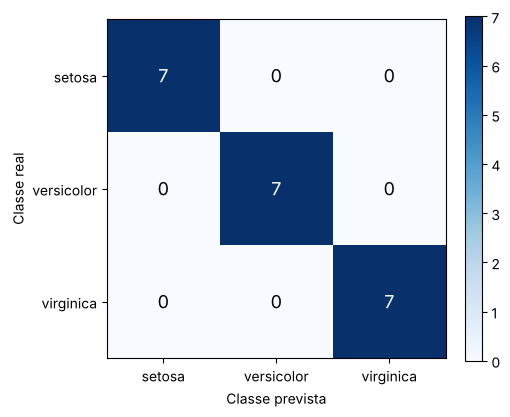

In [38]:
res_va = avaliar(rede, d["Xva"], d["yva"])
res_te = avaliar(rede, d["Xte"], d["yte"])
print(f"Acurácia teste = {res_te['acuracia']:.4f} | F1 macro = {res_te['macro']['f1']:.4f} | CE = {res_te['loss']:.4f}")
display(pd.DataFrame(res_te["por_classe"]).T.round(4))
plotar_matriz_confusao(res_te["matriz_confusao"], OUTDIR);

> Com apenas 21 amostras de teste (7 por classe), cada erro altera a acurácia em ≈ 4,8 p.p.; por isso a
> estimativa holdout tem alta variância e é complementada pelo k-fold estratificado a seguir.

## 12. Experimentos e validação cruzada k-fold

Em cada fold, a parte de treino é subdividida (85/15, estratificada) para o early stopping, e o z-score é
ajustado só nessa subparte. Varia-se **um fator por vez** em torno da configuração base: neurônios ocultos
{2, 4, 8, 16, 32, 10-6}, taxa de aprendizado {0,005; 0,01; 0,05; 0,1; 0,5} e ativação {sigmoid, tanh, ReLU}.

In [39]:
def executar_kfold(X: np.ndarray, y: np.ndarray, config: Dict[str, object], k: int = 5,
                   seed: int = SEED) -> Dict[str, object]:
    """Validacao cruzada estratificada k-fold da MLP.

    Em cada fold, a parte de treino e' subdividida (85/15, estratificada)
    para o early stopping; o z-score e' ajustado apenas nessa subparte.
    A matriz de confusao agregada soma as predicoes fora-do-fold das 150 amostras.
    """
    accs, f1s, epocas = [], [], []
    cm_total = np.zeros((3, 3), dtype=int)
    for i, (tr, te) in enumerate(kfold_estratificado(y, k, seed)):
        sub_tr, sub_va, _ = split_estratificado(y[tr], (0.85, 0.15, 0.0), seed + i)
        idx_tr, idx_va = tr[sub_tr], tr[sub_va]
        d = preprocessar(X, y, idx_tr, idx_va, te)
        rede = MLP(X.shape[1], config["hidden"], 3, config["activation"], seed + i)
        h = treinar(rede, d["Xtr"], d["Ytr"], d["Xva"], d["Yva"], config["lr"], config["momentum"],
                    config["epochs"], config["batch_size"], config["patience"], seed + i)
        m = avaliar(rede, d["Xte"], d["yte"])
        cm_total += np.asarray(m["matriz_confusao"])
        accs.append(m["acuracia"])
        f1s.append(m["macro"]["f1"])
        epocas.append(h["best_epoch"])
    return {"acc_folds": accs, "acc_media": float(np.mean(accs)), "acc_dp": float(np.std(accs, ddof=1)),
            "f1_media": float(np.mean(f1s)), "f1_dp": float(np.std(f1s, ddof=1)),
            "best_epoch_medio": float(np.mean(epocas)), "matriz_confusao_total": cm_total.tolist()}

12:50:03 INFO Early stopping na epoca 173 (melhor epoca: 73)


12:50:04 INFO Early stopping na epoca 533 (melhor epoca: 433)


12:50:07 INFO Early stopping na epoca 171 (melhor epoca: 71)


12:50:07 INFO Early stopping na epoca 155 (melhor epoca: 55)


Acurácia por fold: [1.     0.9333 0.9333 1.     1.    ]
k-fold (k=5): acurácia = 0.9733 ± 0.0365 | F1 macro = 0.9732 ± 0.0367


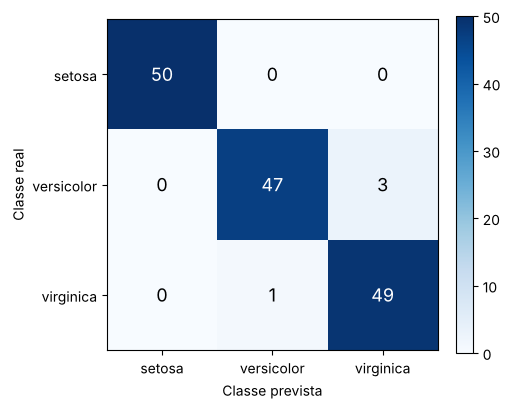

In [40]:
kf = executar_kfold(X, y, config, 5, SEED)
print("Acurácia por fold:", np.round(kf["acc_folds"], 4))
print(f"k-fold (k=5): acurácia = {kf['acc_media']:.4f} ± {kf['acc_dp']:.4f} | F1 macro = {kf['f1_media']:.4f} ± {kf['f1_dp']:.4f}")
plotar_matriz_confusao(kf["matriz_confusao_total"], OUTDIR, "matriz_confusao_kfold");

In [41]:
def executar_experimentos(X: np.ndarray, y: np.ndarray, base: Dict[str, object], k: int = 5,
                          seed: int = SEED) -> List[Dict[str, object]]:
    """Varia um fator por vez (neuronios ocultos, taxa de aprendizado, ativacao)
    em torno da configuracao base, avaliando cada variante por k-fold."""
    grade = (
        [("hidden", h) for h in ([2], [4], [8], [16], [32], [10, 6])]
        + [("lr", v) for v in (0.005, 0.01, 0.05, 0.1, 0.5)]
        + [("activation", a) for a in ("sigmoid", "tanh", "relu")]
    )
    linhas = []
    for fator, valor in grade:
        cfg = {**base, fator: valor}
        t0 = time.perf_counter()
        r = executar_kfold(X, y, cfg, k, seed)
        linhas.append({"fator": fator, "valor": valor, "hidden": cfg["hidden"], "activation": cfg["activation"],
                       "lr": cfg["lr"], **{c: r[c] for c in ("acc_media", "acc_dp", "f1_media", "f1_dp",
                                                             "best_epoch_medio")},
                       "tempo_s": round(time.perf_counter() - t0, 2)})
        LOGGER.info("Exp. %-10s = %-8s | acc %.4f +- %.4f | F1 %.4f", fator, valor, r["acc_media"],
                    r["acc_dp"], r["f1_media"])
    return linhas

In [42]:
def plotar_experimentos(linhas: List[Dict[str, object]], outdir: Path) -> plt.Figure:
    """Acuracia media (+- DP) do k-fold para cada fator variado."""
    fatores = [("hidden", "Neurônios ocultos"), ("lr", "Taxa de aprendizado"), ("activation", "Ativação")]
    fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
    for ax, (f, titulo) in zip(axes, fatores):
        sel = [r for r in linhas if r["fator"] == f]
        rot = ["-".join(map(str, r["valor"])) if isinstance(r["valor"], list) else str(r["valor"]) for r in sel]
        ax.bar(range(len(sel)), [r["acc_media"] for r in sel], yerr=[r["acc_dp"] for r in sel],
               color=CORES[0], alpha=0.8, capsize=4)
        ax.set_xticks(range(len(sel)), rot)
        ax.set_title(titulo)
        ax.grid(axis="y", alpha=0.3)
    axes[0].set_ylabel("Acurácia média (k-fold)")
    axes[0].set_ylim(0.85, 1.02)
    fig.tight_layout()
    _salvar(fig, outdir, "experimentos")
    return fig

12:50:08 INFO Early stopping na epoca 243 (melhor epoca: 143)


12:50:08 INFO Early stopping na epoca 249 (melhor epoca: 149)


12:50:10 INFO Early stopping na epoca 439 (melhor epoca: 339)


12:50:11 INFO Early stopping na epoca 510 (melhor epoca: 410)


12:50:11 INFO Exp. hidden     = [2]      | acc 0.9667 +- 0.0236 | F1 0.9666


...

12:50:48 INFO Early stopping na epoca 897 (melhor epoca: 797)


12:50:48 INFO Early stopping na epoca 237 (melhor epoca: 137)


12:50:49 INFO Early stopping na epoca 726 (melhor epoca: 626)


12:50:49 INFO Exp. activation = relu     | acc 0.9667 +- 0.0333 | F1 0.9666


,fator,valor,acc_media,acc_dp,f1_media,best_epoch_medio,tempo_s
0,hidden,[2],0.9667,0.0236,0.9666,606.8,3.45
1,hidden,[4],0.9800,0.0298,0.9800,227.6,1.52
2,hidden,[8],0.9733,0.0365,0.9732,523.4,3.01
3,hidden,[16],0.9800,0.0298,0.9800,263.2,1.83
4,hidden,[32],0.9733,0.0279,0.9732,261.2,1.99
5,hidden,"[10, 6]",0.9667,0.0236,0.9666,368.4,2.97
6,lr,0.005,0.9733,0.0365,0.9732,907.0,4.51
7,lr,0.01,0.9733,0.0365,0.9732,673.4,3.52
8,lr,0.05,0.9733,0.0365,0.9732,523.4,2.78
9,lr,0.1,0.9800,0.0298,0.9798,499.8,3.16


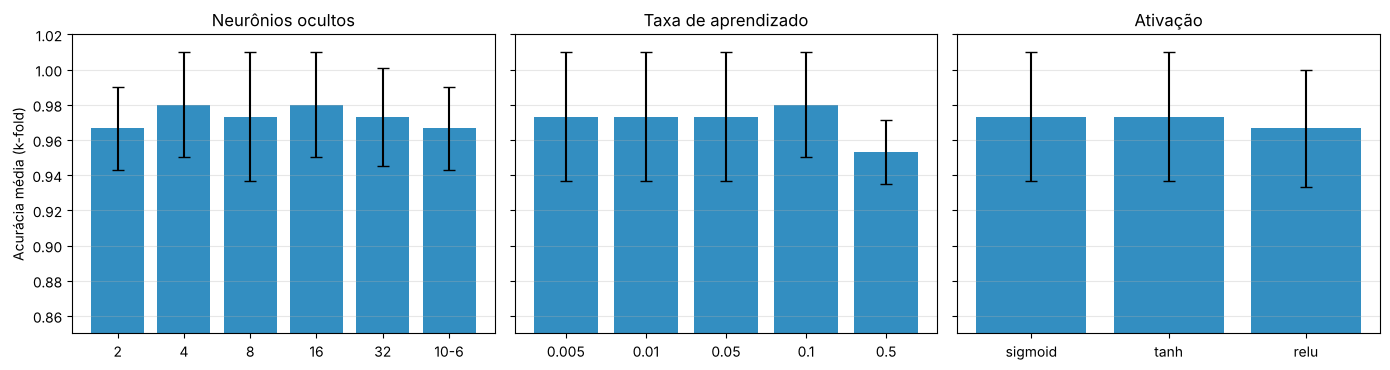

In [43]:
exps = executar_experimentos(X, y, config, 5, SEED)
tab = pd.DataFrame(exps)[["fator", "valor", "acc_media", "acc_dp", "f1_media", "best_epoch_medio", "tempo_s"]]
display(tab.round(4))
plotar_experimentos(exps, OUTDIR);

**Análise Versicolor × Virginica.** A matriz de confusão agregada do k-fold (predições fora-do-fold das 150
amostras) mostra que a *Setosa* nunca é confundida, e todos os erros ocorrem entre *Versicolor* e
*Virginica* — exatamente o par não linearmente separável apontado pela documentação UCI, cujas amostras se
sobrepõem na região de pétalas intermediárias. As variações de hiperparâmetros produzem diferenças menores
que o desvio-padrão entre folds, ou seja, o problema é pouco sensível à arquitetura dentro da faixa testada.

## 13. Baselines (scikit-learn — apenas comparação)

Regressão logística multinomial (modelo linear com Softmax — equivale a uma MLP **sem** camada oculta) e
k-NN ($k=5$), com o mesmo split holdout e os mesmos 5 folds.

In [44]:
def baselines(X: np.ndarray, y: np.ndarray, idx_tr: np.ndarray, idx_te: np.ndarray, k: int = 5,
              seed: int = SEED) -> Dict[str, Dict[str, float]]:
    """Baselines do scikit-learn (APENAS para comparacao): regressao logistica
    multinomial e k-NN (k=5), no mesmo split holdout e nos mesmos folds."""
    from sklearn.linear_model import LogisticRegression
    from sklearn.neighbors import KNeighborsClassifier

    modelos = {"Regressao logistica multinomial": lambda: LogisticRegression(max_iter=2000),
               "k-NN (k=5)": lambda: KNeighborsClassifier(n_neighbors=5)}
    res = {}
    for nome, fabrica in modelos.items():
        sc = ZScore().fit(X[idx_tr])
        clf = fabrica().fit(sc.transform(X[idx_tr]), y[idx_tr])
        hold = metricas_classificacao(y[idx_te], clf.predict(sc.transform(X[idx_te])))
        accs = []
        for tr, te in kfold_estratificado(y, k, seed):
            sc = ZScore().fit(X[tr])
            c = fabrica().fit(sc.transform(X[tr]), y[tr])
            accs.append(float(np.mean(c.predict(sc.transform(X[te])) == y[te])))
        res[nome] = {"acc_teste": hold["acuracia"], "f1_macro_teste": hold["macro"]["f1"],
                     "acc_kfold_media": float(np.mean(accs)), "acc_kfold_dp": float(np.std(accs, ddof=1))}
        LOGGER.info("Baseline %-32s | teste %.4f | k-fold %.4f +- %.4f", nome, res[nome]["acc_teste"],
                    res[nome]["acc_kfold_media"], res[nome]["acc_kfold_dp"])
    return res

In [45]:
base = baselines(X, y, idx_tr, idx_te, 5, SEED)
comp = pd.DataFrame(base).T
comp.loc["MLP 4-8-3 (este trabalho)"] = [res_te["acuracia"], res_te["macro"]["f1"], kf["acc_media"], kf["acc_dp"]]
comp.round(4)

12:50:51 INFO Baseline Regressao logistica multinomial  | teste 1.0000 | k-fold 0.9667 +- 0.0333


12:50:51 INFO Baseline k-NN (k=5)                       | teste 1.0000 | k-fold 0.9467 +- 0.0298


,acc_teste,f1_macro_teste,acc_kfold_media,acc_kfold_dp
Regressao logistica multinomial,1.0,1.0,0.9667,0.0333
k-NN (k=5),1.0,1.0,0.9467,0.0298
MLP 4-8-3 (este trabalho),1.0,1.0,0.9733,0.0365


## 14. Fronteira de decisão (petal length × petal width)

Para visualização, treina-se uma MLP auxiliar com a mesma configuração usando **apenas** os dois
atributos de pétala (mesmo split). As regiões são calculadas numa grade em cm, transformada pelo z-score do
treino. Estrelas = amostras de teste.

In [46]:
def treinar_fronteira(X: np.ndarray, y: np.ndarray, idx_tr: np.ndarray, idx_va: np.ndarray,
                      idx_te: np.ndarray, config: Dict[str, object], seed: int = SEED
                      ) -> Tuple[MLP, ZScore, Dict[str, object]]:
    """Treina uma MLP auxiliar so com petal length x petal width (para visualizacao 2-D)."""
    X2 = X[:, 2:4]
    d = preprocessar(X2, y, idx_tr, idx_va, idx_te)
    rede = MLP(2, config["hidden"], 3, config["activation"], seed)
    treinar(rede, d["Xtr"], d["Ytr"], d["Xva"], d["Yva"], config["lr"], config["momentum"],
            config["epochs"], config["batch_size"], config["patience"], seed)
    return rede, d["scaler"], avaliar(rede, d["Xte"], d["yte"])

In [47]:
def plotar_fronteira(rede: MLP, scaler: ZScore, X: np.ndarray, y: np.ndarray, idx_te: np.ndarray,
                     outdir: Path) -> plt.Figure:
    """Regioes de decisao da MLP 2-D no plano petal length x petal width (em cm)."""
    x_min, x_max = X[:, 2].min() - 0.5, X[:, 2].max() + 0.5
    y_min, y_max = X[:, 3].min() - 0.3, X[:, 3].max() + 0.3
    gx, gy = np.meshgrid(np.linspace(x_min, x_max, 400), np.linspace(y_min, y_max, 400))
    grade = scaler.transform(np.c_[gx.ravel(), gy.ravel()])
    zz = rede.predict(grade).reshape(gx.shape)
    from matplotlib.colors import ListedColormap
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.contourf(gx, gy, zz, levels=[-0.5, 0.5, 1.5, 2.5], cmap=ListedColormap(CORES), alpha=0.25)
    ax.contour(gx, gy, zz, levels=[0.5, 1.5], colors="k", linewidths=0.8)
    eh_teste = np.zeros(len(y), dtype=bool)
    eh_teste[idx_te] = True
    for k, c in enumerate(CLASSES):
        m = y == k
        ax.scatter(X[m & ~eh_teste, 2], X[m & ~eh_teste, 3], color=CORES[k], s=18, label=f"{c} (treino/val.)")
        ax.scatter(X[m & eh_teste, 2], X[m & eh_teste, 3], color=CORES[k], s=55, marker="*",
                   edgecolors="k", linewidths=0.6, label=f"{c} (teste)")
    ax.set_xlabel("petal length (cm)")
    ax.set_ylabel("petal width (cm)")
    ax.legend(fontsize=8, loc="upper left")
    fig.tight_layout()
    _salvar(fig, outdir, "fronteira_decisao")
    return fig

12:50:52 INFO Early stopping na epoca 184 (melhor epoca: 84)


MLP 2-D: acurácia de teste = 1.0000


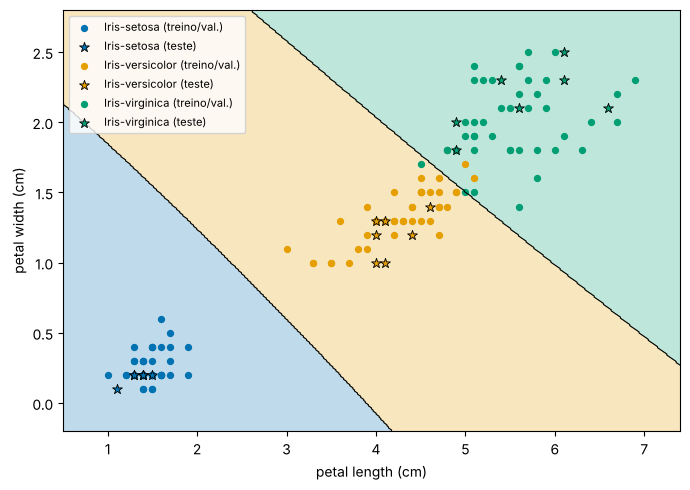

In [48]:
rede2, sc2, res2 = treinar_fronteira(X, y, idx_tr, idx_va, idx_te, config, SEED)
print(f"MLP 2-D: acurácia de teste = {res2['acuracia']:.4f}")
plotar_fronteira(rede2, sc2, X, y, idx_te, OUTDIR);

## 15. Resultados consolidados e conferência com o script

Os resultados são gravados em `resultados_notebook.json` e comparados com o `resultados.json` produzido por
`python iris_mlp.py` (configuração padrão). Com a mesma semente, os dois devem ser idênticos.

In [49]:
def montar_resultados(config: Dict[str, object], seed: int, corrigir_uci: bool, tamanhos: Dict[str, int],
                      n_parametros: int, grad_check: Dict[str, float], hist: Dict[str, object],
                      teste: Dict[str, object], validacao: Dict[str, object], kfold: Optional[Dict[str, object]],
                      experimentos: Optional[List[Dict[str, object]]], base: Optional[Dict[str, object]],
                      fronteira: Dict[str, object], estatisticas: Dict[str, object]) -> Dict[str, object]:
    """Agrupa hiperparametros e metricas em um dicionario serializavel."""
    return {
        "hiperparametros": {**config, "seed": seed, "corrigir_uci": corrigir_uci,
                            "inicializacao": "He" if config["activation"] == "relu" else "Xavier",
                            "otimizador": "SGD mini-batch + momentum", "n_parametros": n_parametros},
        "tamanhos": tamanhos,
        "gradient_check": grad_check,
        "treinamento": {"best_epoch": hist["best_epoch"], "epocas_executadas": hist["epocas_executadas"],
                        "loss_tr_final": hist["loss_tr"][hist["best_epoch"] - 1],
                        "loss_va_final": hist["loss_va"][hist["best_epoch"] - 1],
                        "acc_tr_final": hist["acc_tr"][hist["best_epoch"] - 1],
                        "acc_va_final": hist["acc_va"][hist["best_epoch"] - 1]},
        "validacao": validacao,
        "teste": teste,
        "kfold": kfold,
        "experimentos": experimentos,
        "baselines": base,
        "fronteira_2d": {"acuracia_teste": fronteira["acuracia"], "matriz_confusao": fronteira["matriz_confusao"]},
        "estatisticas": estatisticas,
        "ambiente": {"python": platform.python_version(), "numpy": np.__version__, "pandas": pd.__version__},
    }

In [50]:
resultados = montar_resultados(config, SEED, CORRIGIR_UCI,
                               {"treino": len(idx_tr), "validacao": len(idx_va), "teste": len(idx_te)},
                               rede.n_parametros(), grad_check, hist, res_te, res_va, kf, exps, base, res2,
                               comparar_estatisticas_uci(df))
Path("resultados_notebook.json").write_text(json.dumps(resultados, indent=2, ensure_ascii=False), encoding="utf-8")

def _sem_tempo(r):
    r = json.loads(json.dumps(r))
    for e in r.get("experimentos") or []:
        e.pop("tempo_s", None)
    return r

if Path("resultados.json").exists():
    script = json.loads(Path("resultados.json").read_text(encoding="utf-8"))
    iguais = _sem_tempo(script) == _sem_tempo(resultados)
    print("Notebook x script:", "IDÊNTICOS" if iguais else "DIFERENTES (verifique argumentos do script)")
else:
    print("resultados.json não encontrado: execute `python iris_mlp.py` para comparar.")

Notebook x script: IDÊNTICOS


## 16. Conclusões

In [51]:
print(f"Gradient check : erro relativo máx. {max(grad_check.values()):.1e} (< 1e-6)")
print(f"Holdout (n={len(idx_te)}) : acurácia {res_te['acuracia']:.4f} | F1 macro {res_te['macro']['f1']:.4f}")
print(f"k-fold (k=5)   : acurácia {kf['acc_media']:.4f} ± {kf['acc_dp']:.4f}")
for nome, b in base.items():
    print(f"{nome:32s}: k-fold {b['acc_kfold_media']:.4f} ± {b['acc_kfold_dp']:.4f}")
print("Matriz de confusão agregada (k-fold):\n", np.array(kf["matriz_confusao_total"]))

Gradient check : erro relativo máx. 3.5e-08 (< 1e-6)
Holdout (n=21) : acurácia 1.0000 | F1 macro 1.0000
k-fold (k=5)   : acurácia 0.9733 ± 0.0365
Regressao logistica multinomial : k-fold 0.9667 ± 0.0333
k-NN (k=5)                      : k-fold 0.9467 ± 0.0298
Matriz de confusão agregada (k-fold):
 [[50  0  0]
 [ 0 47  3]
 [ 0  1 49]]


1. A MLP implementada do zero — Softmax estável na saída, entropia cruzada e retropropagação manual — tem
   gradientes validados numericamente (erro relativo < $10^{-6}$ para as três ativações).
2. O gradiente na saída reduz-se a $\hat{\mathbf y}-\mathbf y$, o que torna o par Softmax + CE simples,
   numericamente estável e com interpretação probabilística (máxima verossimilhança multinomial).
3. A rede atinge desempenho no patamar descrito na literatura para o Iris; a estimativa mais confiável é a
   do k-fold (média ± DP), pois o teste holdout tem só 21 amostras.
4. *Setosa* é sempre reconhecida; os poucos erros concentram-se no par *Versicolor* × *Virginica*,
   coerente com a sobreposição observada na análise exploratória.
5. O desempenho é robusto a neurônios ocultos, taxa de aprendizado e ativação na faixa testada; o modelo
   linear (regressão logística) já é competitivo, o que confirma que o problema é quase linearmente
   separável — a camada oculta contribui principalmente na fronteira Versicolor/Virginica.